<img src="https://dauphine.psl.eu/fileadmin/_processed_/9/2/csm_damier_logo_Dauphine_f7b37a1ff2.jpg" width="200" style="vertical-align:middle" /> <h1>Master 222: Introduction to Python - Session 5</h1>





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zaltarba/PSL_python_for_finance/blob/main/python_session_5.ipynb)

# Introduction to yfinance

### What is yfinance?

`yfinance` stands for Yahoo Finance, and the `yfinance` library in Python allows you to access financial data from Yahoo! Finance. This can include stock prices, historical data, financial statements, and much more.

### Why use `yfinance`?

If you're interested in financial analysis, algorithmic trading, or just want to understand how the stock market behaves over time, `yfinance` is a great tool to start with. With just a few lines of Python code, you can retrieve vast amounts of financial data.

### Getting Started

Start by importing the library:
```
import yfinance as yf
```
Fetching Data:

You can fetch data for a specific stock or index. Here's how to get the historical data for Apple Inc. (AAPL) for the past month:
```
data = yf.download("AAPL", period="1mo")
print(data)
```

- Fetch the data for AAPL
- Using matplotlib.pyplot, plot the closing prices



In [84]:
import yfinance as yf
import matplotlib.pyplot as plt


/tmp/ipykernel_1364/1839859804.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed


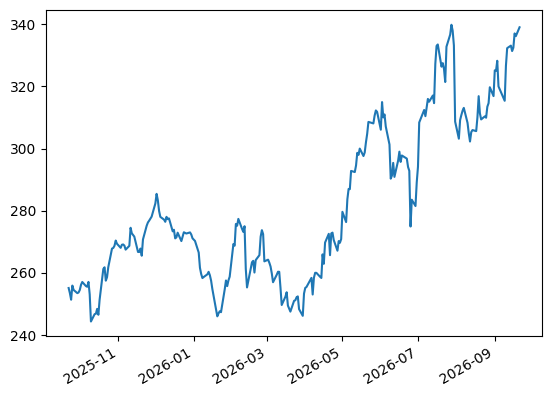

In [85]:
data=yf.download('AAPL', period='1y')
plt.plot(data['Close'])
plt.gcf().autofmt_xdate()
plt.show()

**Exercise: Analyzing Historical Stock Prices**
> Context:
You are a financial analyst at an investment firm. You have been given a dataset containing historical stock prices of several companies over the past decade. Your task is to clean, analyze, and visualize the data to help the firm make informed investment decisions.

> Dataset:
The dataset contains the following columns: 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'.


**Data Loading and Inspection**:

- Fetch the historical stock price data for 'AAPL'.
- Display the first 10 rows of the dataset.
- Check for any missing values in the dataset.

**Data Cleaning**:

- Handle any missing values: You can either fill them using methods such as forward fill, backward fill, or interpolation, or you can choose to drop rows with missing values.
- Convert the 'Date' column to a datetime format if it isn't already..

**Data Transformation**:

- Make the 'Date' column the index of the DataFrame to facilitate time series analysis.
- Compute a new column 'Price_Average', which is the arithmetic mean of the 'High' and 'Low' prices for each trading day.

**Data Analysis**:

- Determine the specific date when the trading volume for Apple Inc. was at its peak.
- Compute the monthly average of the 'Close' price to understand monthly performance trends.

**Data Aggregation**:

- Calculate the total trading volume and average closing price for each company over the period.

**File I/O**:

- Save the cleaned and transformed dataset to a new CSV file.
- Save the plots as image files.

**Bonus**:

- Use a simple linear regression model to attempt predictions of future stock prices based on historical data. This will provide a rudimentary forecast which can be enhanced with more complex models.
- Implement a basic moving average trading strategy. For instance, consider using a 50-day and a 200-day moving average. Generate buy signals when the 50-day moving average crosses above the 200-day moving average, and sell signals when it crosses below. Backtest this strategy to gauge its historical performance.

In [86]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [87]:
tickers=['AAPL','MSFT','TSLA','NVO','MC.PA','OR.PA','NVDA','BNP.PA','TTE.PA']
data=yf.download(tickers,period='10y')
data.head(10)

/tmp/ipykernel_1364/4008341938.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers,period='10y')
[*********************100%***********************]  9 of 9 completed


Price           Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-22  26.211948  27.494654  129.032791  51.342266  1.595126  18.039000   
2016-09-23  25.775156  27.294115  128.656219  50.995953  1.593408  17.765862   
2016-09-26  25.814035  26.401842  126.982651  50.525352  1.578443  17.587730   
2016-09-27  25.862064  26.265249  127.066353  51.457706  1.632415  17.358133   
2016-09-28  26.058733  26.515198  127.526520  51.528732  1.638303  17.314590   
2016-09-29  25.653954  26.393126  126.104012  50.969322  1.653513  16.546637   
2016-09-30  25.852913  26.605295  127.024506  51.146915  1.680990  16.463507   
2016-10-03  25.731703  26.515198  127.191856  50.987083  1.679273  16.277458   
2016-10-04  25.841473  26.756424  131.041092  50.827251  1.675593  16.083492   
2016-10-05  25.852913  27.669041  130.748245  51.182434  1.673876  16.435801   

Price                                              High  ...       Open  \
Ticker           OR.PA       TSLA     TTE.PA       AAPL  ...     TTE.PA   
Date                                                     ...              
2016-09-22  144.867004  13.762000  23.901096  26.285128  ...  23.265473   
2016-09-23  144.269440  13.830000  23.612432  26.250823  ...  23.798400   
2016-09-26  142.263306  13.932667  23.165552  25.930666  ...  23.373726   
2016-09-27  143.031601  13.720667  22.968372  25.882647  ...  23.362728   
2016-09-28  143.799896  13.751333  23.081049  26.216527  ...  23.097949   
2016-09-29  143.116974  13.380000  24.038759  26.024425  ...  24.210586   
2016-09-30  143.501114  13.602000  23.757082  25.926092  ...  23.678211   
2016-10-03  143.629181  14.246667  23.844406  25.852908  ...  23.802153   
2016-10-04  145.421890  14.094000  24.286648  26.141050  ...  23.886659   
2016-10-05  141.879135  13.897333  24.264111  25.992411  ...  23.990878   

Price            Volume                                                 \
Ticker             AAPL     BNP.PA      MC.PA        MSFT         NVDA   
Date                                                                     
2016-09-22  124296000.0  5030250.0   845731.0  19822200.0  308732000.0   
2016-09-23  209924800.0  3697080.0   534423.0  19955300.0  276132000.0   
2016-09-26  119477600.0  3919481.0   524416.0  21688700.0  230040000.0   
2016-09-27   98429600.0  4208318.0   577866.0  28065100.0  402752000.0   
2016-09-28  118564400.0  3447639.0   435720.0  20536400.0  319788000.0   
2016-09-29  143548000.0  2463934.0   479949.0  25463500.0  336684000.0   
2016-09-30  145516400.0  6379925.0   743922.0  29910800.0  429932000.0   
2016-10-03   86807200.0  1773168.0   324385.0  19189500.0  242596000.0   
2016-10-04  118947200.0  2739790.0  1109267.0  20085900.0  281624000.0   
2016-10-05   85812400.0  5192510.0   614540.0  16726400.0  305440000.0   

Price                                                    
Ticker             NVO     OR.PA        TSLA     TTE.PA  
Date                                                     
2016-09-22   4693000.0  665852.0  35743500.0  7651893.0  
2016-09-23   7747800.0  353632.0  43578000.0  5818834.0  
2016-09-26   3881400.0  456439.0  35916000.0  6268784.0  
2016-09-27   6298400.0  433051.0  50598000.0  6137801.0  
2016-09-28   5844600.0  382823.0  31326000.0  4402576.0  
2016-09-29   9584200.0  354474.0  40905000.0  7934813.0  
2016-09-30  11301000.0  580712.0  38794500.0  7665326.0  
2016-10-03   7161800.0  343323.0  89998500.0  4144437.0  
2016-10-04  10758800.0  549128.0  53122500.0  5844520.0  
2016-10-05  10034000.0  487257.0  28162500.0  5933056.0  

[10 rows x 45 columns]

In [88]:
data['Close'].isna().sum()

,0
Ticker,
AAPL,72
BNP.PA,25
MC.PA,25
MSFT,72
NVDA,72
NVO,72
OR.PA,25
TSLA,72
TTE.PA,25


In [89]:
data=data.ffill()
data.isna().any()

Price   Ticker
Close   AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
High    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Low     AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Open    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Volume  AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
dtype: bool

In [90]:
print(data.index.dtype)

datetime64[ns]


In [91]:
data['Price Average'] = data[['High','Low']].mean(axis=1)
data.head(10)

Price           Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-22  26.211948  27.494654  129.032791  51.342266  1.595126  18.039000   
2016-09-23  25.775156  27.294115  128.656219  50.995953  1.593408  17.765862   
2016-09-26  25.814035  26.401842  126.982651  50.525352  1.578443  17.587730   
2016-09-27  25.862064  26.265249  127.066353  51.457706  1.632415  17.358133   
2016-09-28  26.058733  26.515198  127.526520  51.528732  1.638303  17.314590   
2016-09-29  25.653954  26.393126  126.104012  50.969322  1.653513  16.546637   
2016-09-30  25.852913  26.605295  127.024506  51.146915  1.680990  16.463507   
2016-10-03  25.731703  26.515198  127.191856  50.987083  1.679273  16.277458   
2016-10-04  25.841473  26.756424  131.041092  50.827251  1.675593  16.083492   
2016-10-05  25.852913  27.669041  130.748245  51.182434  1.673876  16.435801   

Price                                              High  ...       Volume  \
Ticker           OR.PA       TSLA     TTE.PA       AAPL  ...         AAPL   
Date                                                     ...                
2016-09-22  144.867004  13.762000  23.901096  26.285128  ...  124296000.0   
2016-09-23  144.269440  13.830000  23.612432  26.250823  ...  209924800.0   
2016-09-26  142.263306  13.932667  23.165552  25.930666  ...  119477600.0   
2016-09-27  143.031601  13.720667  22.968372  25.882647  ...   98429600.0   
2016-09-28  143.799896  13.751333  23.081049  26.216527  ...  118564400.0   
2016-09-29  143.116974  13.380000  24.038759  26.024425  ...  143548000.0   
2016-09-30  143.501114  13.602000  23.757082  25.926092  ...  145516400.0   
2016-10-03  143.629181  14.246667  23.844406  25.852908  ...   86807200.0   
2016-10-04  145.421890  14.094000  24.286648  26.141050  ...  118947200.0   
2016-10-05  141.879135  13.897333  24.264111  25.992411  ...   85812400.0   

Price                                                                  \
Ticker         BNP.PA      MC.PA        MSFT         NVDA         NVO   
Date                                                                    
2016-09-22  5030250.0   845731.0  19822200.0  308732000.0   4693000.0   
2016-09-23  3697080.0   534423.0  19955300.0  276132000.0   7747800.0   
2016-09-26  3919481.0   524416.0  21688700.0  230040000.0   3881400.0   
2016-09-27  4208318.0   577866.0  28065100.0  402752000.0   6298400.0   
2016-09-28  3447639.0   435720.0  20536400.0  319788000.0   5844600.0   
2016-09-29  2463934.0   479949.0  25463500.0  336684000.0   9584200.0   
2016-09-30  6379925.0   743922.0  29910800.0  429932000.0  11301000.0   
2016-10-03  1773168.0   324385.0  19189500.0  242596000.0   7161800.0   
2016-10-04  2739790.0  1109267.0  20085900.0  281624000.0  10758800.0   
2016-10-05  5192510.0   614540.0  16726400.0  305440000.0  10034000.0   

Price                                       Price Average  
Ticker         OR.PA        TSLA     TTE.PA                
Date                                                       
2016-09-22  665852.0  35743500.0  7651893.0     48.221341  
2016-09-23  353632.0  43578000.0  5818834.0     48.225930  
2016-09-26  456439.0  35916000.0  6268784.0     47.707774  
2016-09-27  433051.0  50598000.0  6137801.0     47.679272  
2016-09-28  382823.0  31326000.0  4402576.0     47.992052  
2016-09-29  354474.0  40905000.0  7934813.0     47.901917  
2016-09-30  580712.0  38794500.0  7665326.0     47.330611  
2016-10-03  343323.0  89998500.0  4144437.0     47.707904  
2016-10-04  549128.0  53122500.0  5844520.0     48.143118  
2016-10-05  487257.0  28162500.0  5933056.0     48.154296  

[10 rows x 46 columns]

In [92]:
max_volume_date=data['Volume'].idxmax()
max_volume_date

,0
Ticker,
AAPL,2017-02-01
BNP.PA,2020-03-12
MC.PA,2020-03-12
MSFT,2026-06-26
NVDA,2017-06-09
NVO,2025-07-29
OR.PA,2020-03-12
TSLA,2020-02-04
TTE.PA,2020-03-09


In [94]:
monthly_close_mean = data['Close'].resample('ME').mean()
monthly_volume_sum = data['Volume'].resample('ME').sum()

monthly_data = pd.concat([monthly_close_mean, monthly_volume_sum], axis=1, keys=['Close', 'Volume'])
monthly_data.head(10)

Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-30  25.889829  26.709926  127.484722  51.138035  1.624600  17.296494   
2016-10-31  26.460563  28.993949  136.647578  51.855175  1.672054  15.862190   
2016-11-30  25.319373  31.426239  138.777064  53.428438  2.049397  13.182430   
2016-12-31  26.281180  34.651625  149.408170  55.531464  2.447972  13.975480   
2017-01-31  27.439615  35.417269  156.459725  56.428756  2.592369  14.178179   
2017-02-28  30.853049  33.087173  158.853171  57.530256  2.711209  13.801993   
2017-03-31  32.462515  35.041469  167.610777  58.317338  2.554728  13.516512   
2017-04-30  32.986334  35.680335  179.272022  59.513771  2.488233  14.661184   
2017-05-31  35.252135  38.495618  196.625899  62.209562  3.100068  16.489456   
2017-06-30  34.268674  38.104816  195.046077  63.786581  3.724074  17.519582   

                                                    Volume               \
Ticker           OR.PA       TSLA     TTE.PA          AAPL       BNP.PA   
Date                                                                      
2016-09-30  143.549905  13.711238  23.503478  9.597568e+08   29146627.0   
2016-10-31  141.702326  13.445555  24.651490  2.747657e+09   93386518.0   
2016-11-30  137.203397  12.622576  24.452839  2.995926e+09   87049992.0   
2016-12-31  142.903556  13.370190  26.677155  2.435087e+09   85733922.0   
2017-01-31  145.765278  15.872273  27.461775  2.479281e+09   66098503.0   
2017-02-28  147.837744  17.609133  27.105310  2.388667e+09   73510271.0   
2017-03-31  151.521863  17.210435  26.952896  2.246514e+09   91362982.0   
2017-04-30  155.286479  20.317228  27.616424  1.493216e+09  102736480.0   
2017-05-31  163.432621  21.126580  27.642046  2.703638e+09  117038933.0   
2017-06-30  164.718410  24.386909  26.321374  2.736712e+09   92500449.0   

                                                                            \
Ticker           MC.PA         MSFT          NVDA          NVO       OR.PA   
Date                                                                         
2016-09-30   4142027.0  165442000.0  2.304060e+09   49350400.0   3226983.0   
2016-10-31  15023241.0  614841800.0  6.551568e+09  184098000.0  10659442.0   
2016-11-30  15045398.0  634905700.0  1.321070e+10  239742400.0  14286733.0   
2016-12-31  14366421.0  513579700.0  1.808223e+10  128372000.0  11706749.0   
2017-01-31  15828892.0  538455700.0  1.506759e+10  102925200.0  11769189.0   
2017-02-28  10836338.0  461992800.0  1.477053e+10  118731200.0  13553994.0   
2017-03-31  12553357.0  489169700.0  1.428896e+10   91159600.0  12911497.0   
2017-04-30  14670200.0  433191200.0  9.572572e+09  100472000.0  12421918.0   
2017-05-31  14369920.0  537046400.0  1.998858e+10  104723400.0  12948644.0   
2017-06-30  13960285.0  629716800.0  2.344552e+10   84283000.0  13557582.0   

                                       
Ticker              TSLA       TTE.PA  
Date                                   
2016-09-30  2.768610e+08   45880027.0  
2016-10-31  1.381992e+09  108745177.0  
2016-11-30  1.556668e+09  120295896.0  
2016-12-31  1.319901e+09  133886479.0  
2017-01-31  1.671228e+09   98979744.0  
2017-02-28  1.886956e+09   96148800.0  
2017-03-31  1.605530e+09  133095815.0  
2017-04-30  1.754259e+09  124176400.0  
2017-05-31  2.337728e+09  135430985.0  
2017-06-30  2.789266e+09  141750841.0

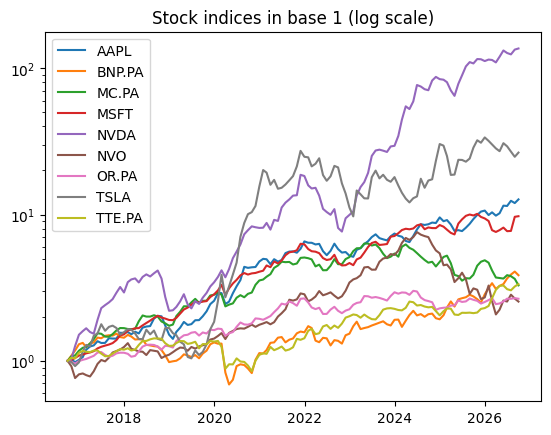

In [107]:
monthly_prices_rebased=monthly_data['Close']/monthly_data['Close'].iloc[0]
plt.plot(monthly_prices_rebased)
plt.title('Stock indices in base 1 (log scale)')
plt.legend(monthly_prices_rebased.columns)
plt.yscale('log')
plt.show()

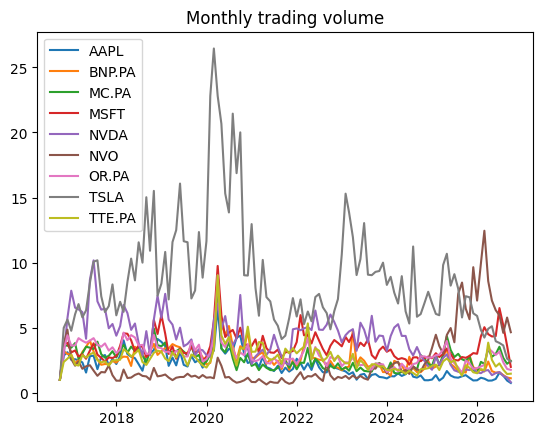

In [106]:
monthly_volume_rebased=monthly_data['Volume']/monthly_data['Volume'].iloc[0]
plt.plot(monthly_volume_rebased)
plt.title('Monthly trading volume')
plt.legend(monthly_volume_rebased.columns)
plt.show()

**Exercice TO DO: Momentum Strategy on 50 Stocks**

## Objective
Explore the performance of a simple momentum strategy on a subset of 50 stocks.

## Procedure

### 1. Stock Selection
- Use `pandas` to fetch the list of all tickers from [this link](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies)
    - Use pd.read_html
- Randomly select 50 stocks from this list.

### 2. Data Collection
- For each stock, download the daily adjusted closing prices for the last 365 days.
- Store this data in a pandas DataFrame with dates as the index.

### 3. Momentum Calculation
- Define momentum as the percentage change in the stock price over the previous n days (e.g., n=21 for a month).
- Using pandas, compute the momentum for each stock for each day.
- Rank the stocks based on their momentum every day.

### 4. Strategy

1. At the beginning of each month, buy the top 10 stocks based on momentum from the previous month.
2. At the end of the month, sell all the stocks.
3. Repeat this process for each month in your dataset.

### 5. Performance Analysis

- Calculate the monthly and annualized return of this strategy.
- Compare the strategy's performance against a benchmark (e.g., S&P 500).
- Plot the cumulative returns of your strategy and the benchmark.

### 6. Risk Analysis
- Using numpy, compute the standard deviation of the monthly returns to get a measure of the strategy's risk.
- Calculate the Sharpe Ratio.

## Hints

- To get the tickers list:
```python
import requests

# URL of the Wikipedia page
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Set headers to mimic a browser
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send the HTTP request with custom headers
response = requests.get(url, headers=headers)

# Use pandas to read the HTML from the response content
tables = pd.read_html(response.text)
```

In [ ]:
## Insert your code here